### **Singular Value Decomposition (SVD)**

Singular Value Decomposition (SVD) is a powerful matrix factorization technique that has wide applications in various fields, including linear algebra, data analysis, signal processing, and computer science. It decomposes any matrix into three other matrices.

For any $m \times n$ matrix $A$, the SVD is given by:

$A = U \Sigma V^T$

Where:

*   $U$ is an $m \times m$ orthogonal matrix whose columns are the left singular vectors of $A$.
*   $\Sigma$ is an $m \times n$ rectangular diagonal matrix with non-negative real numbers on the diagonal. These diagonal entries are the singular values of $A$, usually sorted in descending order. The singular values are the square roots of the eigenvalues of $A^T A$ (or $A A^T$).
*   $V^T$ is the transpose of an $n \times n$ orthogonal matrix $V$, whose columns are the right singular vectors of $A$.

**SVD** essentially decomposes a matrix $A$ into a set of orthogonal basis vectors for the column space ($U$) and row space ($V$), and a diagonal matrix ($\Sigma$) that scales these basis vectors according to the "importance" or "strength" of the corresponding singular values.

The singular values in $\Sigma$ represent the magnitude of the linear transformation along the directions defined by the corresponding singular vectors. Larger singular values indicate directions where the transformation has a greater effect.

In [1]:
#Import Libs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
#Import Database
df = pd.read_csv('https://raw.githubusercontent.com/jrafa1607/DataScience-ML-AI/main/-%20Datasets/diabetes.csv')

In [3]:
#Show the Dataframe
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
#Get the Data X ( All attributes, except the Outcome )
df_features = df.drop('Outcome', axis=1)

In [5]:
#Apply Standard Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

In [6]:
#Show the Results
df_features

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [7]:
#Reduce to 3 Attributes ( Components )
svd = TruncatedSVD(n_components=3)
df_svd = svd.fit_transform(df_scaled)

In [8]:
#Transform the Results in Dataframe
df_svd_result = pd.DataFrame(df_svd)

In [9]:
#Change the Columns Name
df_svd_result.columns = [f'SVD_Component_{i+1}' for i in range(df_svd.shape[1])]

In [10]:
#Combine the Reduce Dataframe by SVD with the Outbome Attribute
df_combined = pd.concat([df_svd_result, df['Outcome']], axis=1)

In [11]:
#Show the Results
df_combined

,SVD_Component_1,SVD_Component_2,SVD_Component_3,Outcome
0,1.068503,1.234895,-0.095930,1
1,-1.121683,-0.733852,0.712938,0
2,-0.396477,1.595876,-1.760678,1
3,-1.115781,-1.271241,0.663729,0
4,2.359334,-2.184819,-2.963107,1
...,...,...,...,...
763,1.562085,1.923150,0.867408,0
764,-0.100405,-0.614181,0.764353,0
765,-0.283475,0.097065,0.077192,0
766,-1.060324,0.837062,-0.425030,1


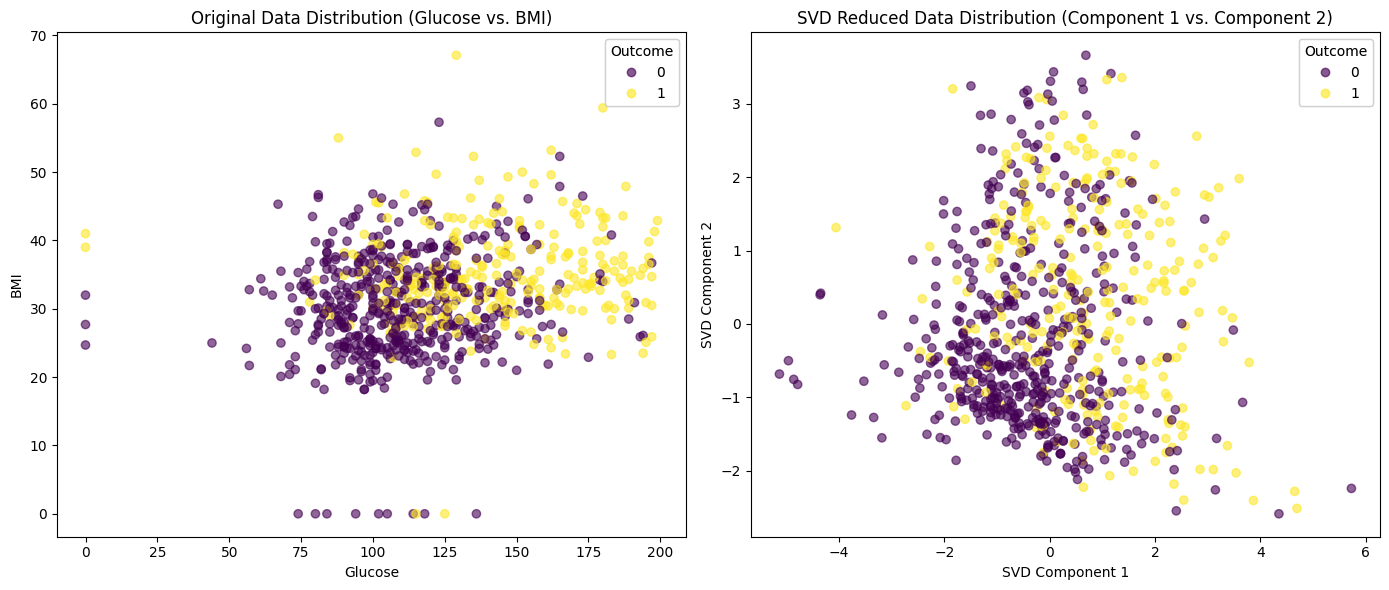

In [12]:
#Show the Figures
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for original data
scatter1 = axes[0].scatter(df_features['Glucose'], df_features['BMI'], c=df_combined['Outcome'], cmap='viridis', alpha=0.6)
axes[0].set_title('Original Data Distribution (Glucose vs. BMI)')
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('BMI')
legend1 = axes[0].legend(*scatter1.legend_elements(), title="Outcome")
axes[0].add_artist(legend1)


# Scatter plot for SVD-reduced data
scatter2 = axes[1].scatter(df_combined['SVD_Component_1'], df_combined['SVD_Component_2'], c=df_combined['Outcome'], cmap='viridis', alpha=0.6)
axes[1].set_title('SVD Reduced Data Distribution (Component 1 vs. Component 2)')
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Outcome")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()